In [1]:
import numpy as np
from datascience import *
import matplotlib.pylab as plots
plots.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
wheel = Table.read_table("roulette_wheel.csv")

In [3]:
wheel.show(40)

Pocket,Color
0,green
0,green
1,red
2,black
3,red
4,black
5,red
6,black
7,red
8,black


La apuesta al rojo paga 1 a 1. Hemos definido la función red_winnings que devuelve las ganancias netas de una apuesta de $1 al rojo. Específicamente, la función toma un color como argumento y devuelve 1 si el color es rojo. Para todos los demás colores devuelve -1.

In [4]:
def red_winnings(color):
    if color == 'red':
        return 1
    else:
        return -1

In [5]:
red = wheel.with_column(
    'Winnings: Red', wheel.apply(red_winnings, 'Color')
    )
red

Pocket,Color,Winnings: Red
0,green,-1
0,green,-1
1,red,1
2,black,-1
3,red,1
4,black,-1
5,red,1
6,black,-1
7,red,1
8,black,-1


In [6]:
red.group("Color")

Color,count
black,18
green,2
red,18


In [7]:
print(red.where("Winnings: Red", are.equal_to(1))["Winnings: Red"].sum())
average_win = 1*(18/38) #+ (-1)*(20/38)
average_loss = 1*(20/38) 
print(average_win*100)
print(average_loss*100)

18
47.368421052631575
52.63157894736842


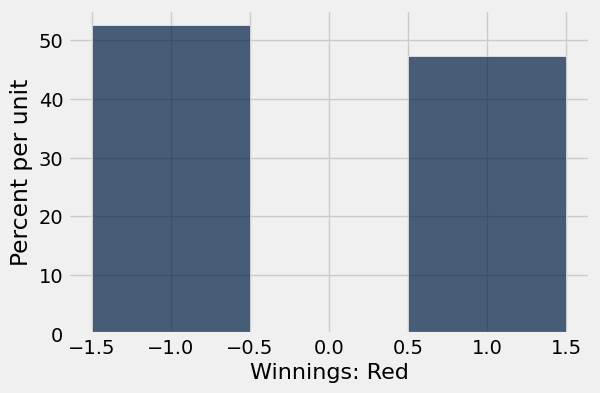

In [8]:
red.select('Winnings: Red').hist(bins=np.arange(-1.5, 1.6, 1))

In [9]:
# Jueguemos 400 veces a la ruleta
num_bets = 400
spins = red.sample(num_bets)
spins

Pocket,Color,Winnings: Red
4,black,-1
11,black,-1
1,red,1
25,red,1
22,black,-1
36,red,1
34,red,1
25,red,1
1,red,1
21,red,1


In [10]:
num_bets = 400
repetitions = 10000
net_gain_red = make_array()
apuesta = 1

for i in range(repetitions):
    spins = red.sample(num_bets)
    new_net_gain_red = spins.column('Winnings: Red').sum()
    net_gain_red = np.append(net_gain_red, new_net_gain_red)

results = Table().with_column('Net Gain on Red', net_gain_red)  
results

Net Gain on Red
2
-18
-2
-18
-28
-18
-28
-24
-14
-22


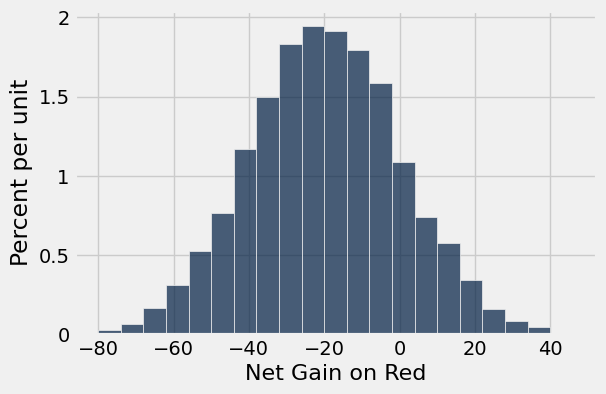

In [11]:
results.hist(bins=np.arange(-80, 50, 6))

Si apuesto un peso, y como la probabilidad de ganar es de 18/38, por cada dolar tengo 
la posiblidad de ganar 1*18/38, Y de perder 20/38, es decir, que en total, tengo la posiblidad de ganar $(1*(18/38) + (-1)*(20/38))$

In [12]:
average_per_bet = 5000*(1*(18/38) + (-1)*(20/38))
average_per_bet

-263.1578947368421

In [13]:
# Si apuesta 5000, el valor de perdida despues de 400 apuesta es de: 
average_per_bet*400

-105263.15789473683

In [14]:
np.std(results.column(0))

20.138109607408534

# Retraso promedio del vuelo

In [15]:
united = Table.read_table("united.csv")

In [16]:
united

Date,Flight Number,Destination,Delay
6/1/15,73,HNL,257
6/1/15,217,EWR,28
6/1/15,237,STL,-3
6/1/15,250,SAN,0
6/1/15,267,PHL,64
6/1/15,273,SEA,-6
6/1/15,278,SEA,-8
6/1/15,292,EWR,12
6/1/15,300,HNL,20
6/1/15,317,IND,-10


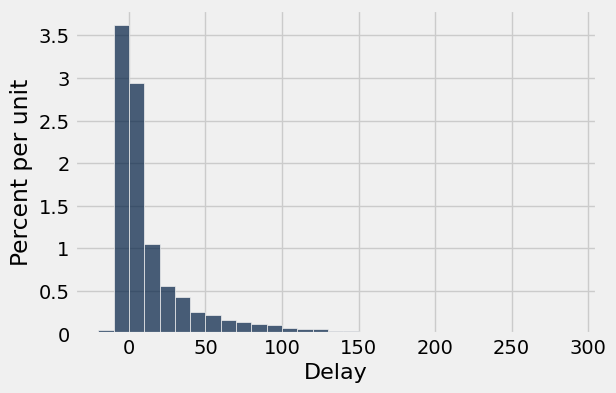

In [17]:
united.select('Delay').hist(bins=np.arange(-20, 300, 10))

In [18]:
mean_delay = np.mean(united.column('Delay'))
sd_delay = np.std(united.column('Delay'))
mean_delay, sd_delay

(16.658155515370705, 39.480199851609314)

In [19]:
# Muestreo
delay = united.select('Delay')

In [20]:
np.mean(delay.sample(400).column('Delay'))

15.262499999999999

In [21]:
sample_size = 400
repetitions = 10000

means = make_array()

for i in np.arange(repetitions):
    sample = delay.sample(sample_size)
    new_mean = np.mean(sample.column('Delay'))
    means = np.append(means, new_mean)

results = Table().with_column(
    'Sample Mean', means
)

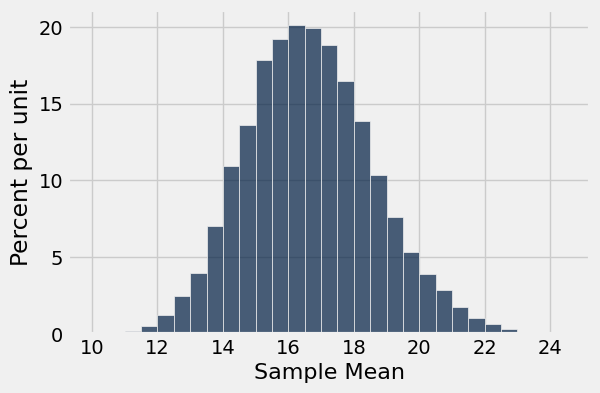

In [22]:
results.hist(bins=np.arange(10, 25, 0.5))

In [23]:
np.mean (results.column(0))

16.657569500000001

In [24]:
np.std (results.column(0))

1.9511272143096539

# Teorema del limite central

El Teorema del Límite Central dice que la distribución de probabilidad de la suma o el promedio de una gran muestra aleatoria extraída con reemplazo será más o menos normal, independientemente de la distribución de la población de la que se extrae la muestra.

# Proporcion de flores moradas



In [30]:
colors = make_array('Purple', 'Purple', 'Purple', 'White')
model = Table().with_column('Color', colors)
model

Color
Purple
Purple
Purple
White


In [33]:
props = make_array()
num_plants = 200
repetitions = 10000

for i in np.arange(repetitions):
    sample = model.sample(num_plants)
    new_prop = np.count_nonzero(sample.column('Color') == 'Purple')/num_plants
    props = np.append(props, new_prop)
    
results = Table().with_column('Sample Proportion: 200', props)

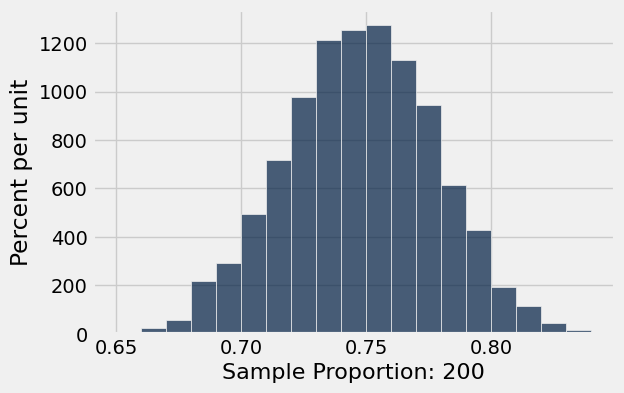

In [34]:
results.hist(bins=np.arange(0.65, 0.85, 0.01))
# Curva normal, centada al rededor de 0.75

In [35]:
props2 = make_array()

num_plants = 800

for i in np.arange(repetitions):
    sample = model.sample(num_plants)
    new_prop = np.count_nonzero(sample.column('Color') == 'Purple')/num_plants
    props2 = np.append(props2, new_prop)
    
results = results.with_column('Sample Proportion: 800', props2)

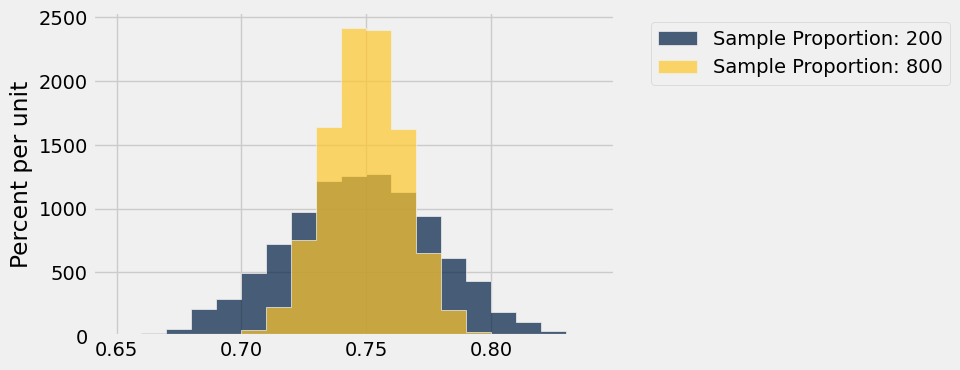

In [36]:
results.hist(bins=np.arange(0.65, 0.85, 0.01))

Ambas distribuciones son aproximadamente normales, pero una es más estrecha que la otra. Las proporciones basadas en un tamaño de muestra de 800 están más estrechamente agrupadas alrededor de 0,75 que las de un tamaño de muestra de 200. Aumentar el tamaño de la muestra ha disminuido la variabilidad en la proporción de la muestra.

¿Exactamente cómo afecta el tamaño de la muestra a la variabilidad del promedio o proporción de una muestra?

# Variabilidad de la media

In [37]:
united = Table.read_table('united.csv')
delay = united.select('Delay')
pop_mean = np.mean(delay.column('Delay'))
pop_mean

16.658155515370705

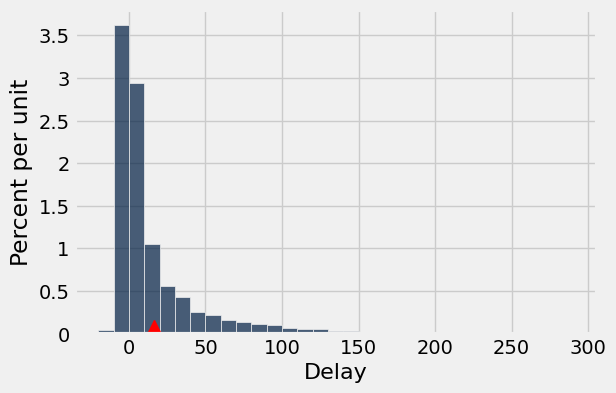

In [38]:
united.select('Delay').hist(bins=np.arange(-20, 300, 10))
plots.plot(pop_mean,0,"^",ms=20,color="red")

In [39]:
# Construyamos una funcion que nos permita definir diferentes muestras sobre un conjunto 
# determinado de experimentos

In [41]:
"""Empirical distribution of random sample means"""

def simulate_sample_mean(table, label, sample_size, repetitions):
    
    means = make_array()

    for i in range(repetitions):
        new_sample = table.sample(sample_size)
        new_sample_mean = np.mean(new_sample.column(label))
        means = np.append(means, new_sample_mean)

    sample_means = Table().with_column('Sample Means', means)
    
    # Display empirical histogram and print all relevant quantities
    sample_means.hist(bins=20)
    plots.xlabel('Sample Means')
    plots.title('Sample Size ' + str(sample_size))
    print("Sample size: ", sample_size)
    print("Population mean:", np.mean(table.column(label)))
    print("Average of sample means: ", np.mean(means))
    print("Population SD:", np.std(table.column(label)))
    print("SD of sample means:", np.std(means))

Sample size:  100
Population mean: 16.6581555154
Average of sample means:  16.691454
Population SD: 39.4801998516
SD of sample means: 3.95989720648


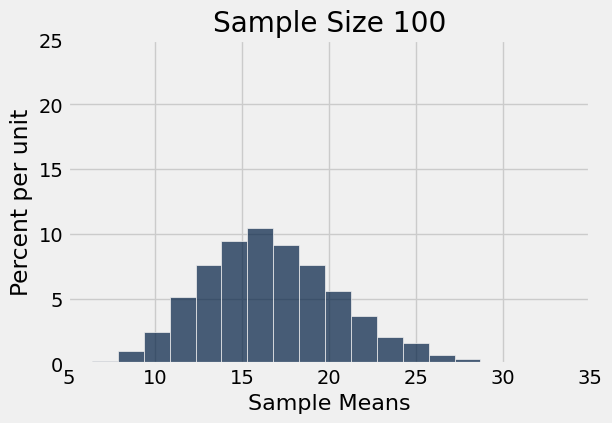

In [43]:
simulate_sample_mean(delay, 'Delay', sample_size=100, repetitions=10000)
plots.xlim(5, 35)
plots.ylim(0, 0.25);

Sample size:  400
Population mean: 16.6581555154
Average of sample means:  16.66919875
Population SD: 39.4801998516
SD of sample means: 1.96659651584


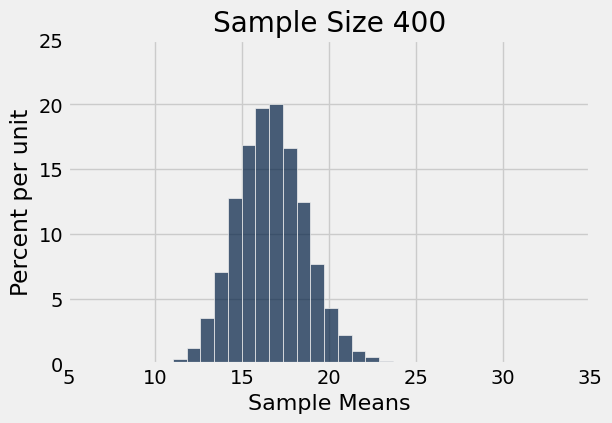

In [44]:
simulate_sample_mean(delay, 'Delay', 400, 10000)
plots.xlim(5, 35)
plots.ylim(0, 0.25);

Sample size:  625
Population mean: 16.6581555154
Average of sample means:  16.68391088
Population SD: 39.4801998516
SD of sample means: 1.58531649041


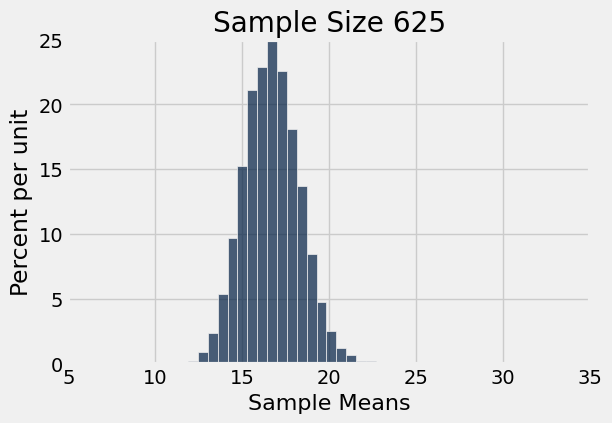

In [45]:
simulate_sample_mean(delay, 'Delay', 625, 10000)
plots.xlim(5, 35)
plots.ylim(0, 0.25);

# El SD de todas las medias de la muestra

In [46]:
pop_sd = np.std(delay.column('Delay'))
pop_sd

39.480199851609314

In [47]:
repetitions = 10000
sample_sizes = np.arange(25, 626, 25)

sd_means = make_array()
mean_mean=make_array()
for n in sample_sizes:
    means = make_array()
    for i in np.arange(repetitions):
        means = np.append(means, np.mean(delay.sample(n).column('Delay')))
    mean_mean=np.append(mean_mean, np.mean(means))
    sd_means = np.append(sd_means, np.std(means))

In [48]:
mean_mean

array([ 16.730896  ,  16.65972   ,  16.68632133,  16.641398  ,
        16.6287616 ,  16.638336  ,  16.58818914,  16.6258595 ,
        16.663896  ,  16.6456876 ,  16.66354909,  16.678307  ,
        16.65985046,  16.62863029,  16.65198987,  16.66041125,
        16.659424  ,  16.67036533,  16.64214421,  16.6917364 ,
        16.65278076,  16.65815127,  16.65632783,  16.66101467,  16.6554168 ])

Text(0.5, 0, 'Sample Size')

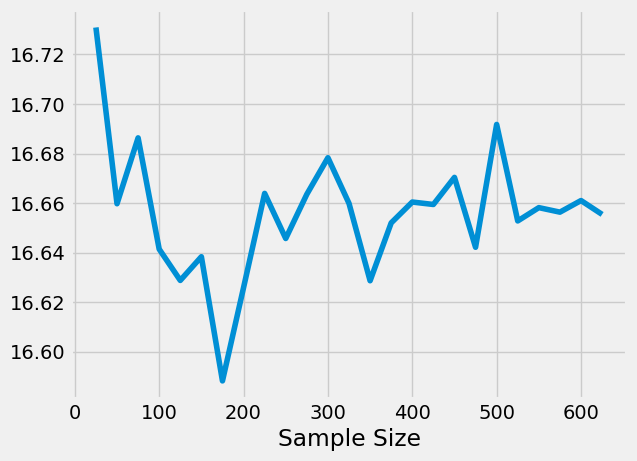

In [49]:
plots.plot(sample_sizes,mean_mean)
plots.xlabel("Means")
plots.xlabel("Sample Size")

In [50]:
sd_comparison = Table().with_columns(
    'Sample Size n', sample_sizes,
    'SD of 10,000 Sample Means', sd_means,
    'pop_sd/sqrt(n)', pop_sd/np.sqrt(sample_sizes),
    "mean_mean", mean_mean
)

In [51]:
sd_comparison

Sample Size n,"SD of 10,000 Sample Means",pop_sd/sqrt(n),mean_mean
25,7.88398,7.89604,16.7309
50,5.5764,5.58334,16.6597
75,4.59731,4.55878,16.6863
100,3.93044,3.94802,16.6414
125,3.52258,3.53122,16.6288
150,3.21562,3.22354,16.6383
175,2.98896,2.98442,16.5882
200,2.79481,2.79167,16.6259
225,2.61444,2.63201,16.6639
250,2.48662,2.49695,16.6457


Text(0, 0.5, 'SD')

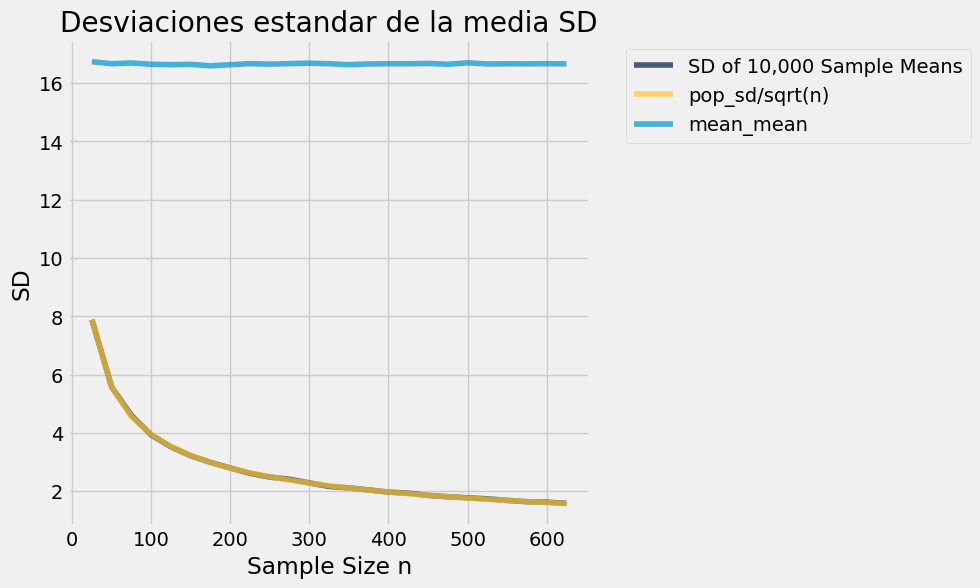

In [52]:
sd_comparison.plot('Sample Size n')
plots.title("Desviaciones estandar de la media SD")
plots.ylabel("SD")



# Desviación estándar de la media muestral

La variabilidad de la **media muestral** está dada por el **error estándar**, denotado por \(S\):

\begin{equation}
S = \frac{\sigma}{\sqrt{N}}
\end{equation}

donde:

- $S$ = error estándar de la media (desviación estándar de las medias muestrales)  
- $\sigma$ = desviación estándar verdadera de la población  
- $N$ = tamaño de la muestra  

Esta fórmula muestra dos ideas fundamentales:

- **El tamaño de la población no influye en la precisión de la media muestral.**  
  El tamaño total de la población no aparece en la ecuación; solo importan $\sigma$ y $N$.

- **La desviación estándar poblacional $\sigma$ es fija.**  
  Representa la variabilidad inherente de la población y se mantiene constante para cualquier muestra tomada de ella.

- **El tamaño de la muestra $N$ determina la precisión de la media.**  
  Como $N$ aparece en el denominador bajo una raíz cuadrada, al aumentar el tamaño de la muestra se reduce el error estándar $S$.  
  Por lo tanto, **muestras más grandes producen estimaciones más estables y precisas de la media poblacional**.


# ¿Cómo elegir el tamano de la muestra?

\begin{equation}
\sqrt{N} = \frac{\sigma}{S}
\end{equation}

In [147]:
from scipy import stats

In [156]:
x = np.linspace(-4.5, 4.5, 100)
sigma = 1
mu = 0
y = stats.norm.pdf(x,mu,sigma)

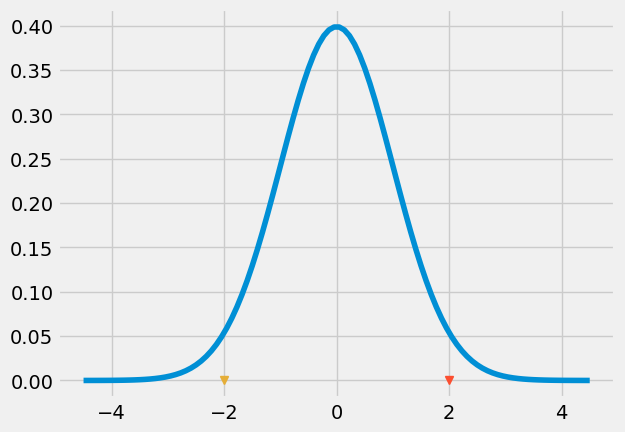

In [157]:
plots.plot(x, y)
plots.plot(2,0,"v")
plots.plot(-2,0,"v")

In [159]:
(stats.norm.cdf(2)-stats.norm.cdf(-2))*100

95.449973610364154

In [151]:
# 2*sigma confiabilidad del 95%

In [155]:
N = (2/0.01)**2
N

40000.0